# 05 - Perspective Projection

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## How Does a Camera Work?

This is not meant to be a trick question. To understand how to manipulate visual objects, we have to understand some basics about how they work. 

The necessity of this will become clear as you work through this notebook. 

### Pinhole Camera

The most basic form of camera is a **pinhole camera**, which consists of a box with a hole on one side to allow light in, and another side that has a light-sensitive paper on it so that an image can be formed (upside down). 

The phenomenon that allows for an image to be created is known as **camera obscura** - it is a pretty cool idea! 

Let's see what this pinhole camera looks like (note that the camera is not to scale): 

![](./ref_imgs/pinhole_camera.png)

Advanced cameras have been built on this fundamental concept. But how is this relevant to robotics? 

Every camera on a robot (a Limelight, a webcam, etc.) is a much more sophisticated descendant of this same pinhole idea. Understanding the geometry of how it forms an image is exactly what lets us go from "a game piece is at pixel (120, 340)" to "that game piece is 2.3 meters away and 15° to the left", the foundation of tasks like AprilTag pose estimation and distance-to-target estimation.

## Perspective Projection

Naturally, the camera is not going to be as large as a tree. The camera might also be bigger than the object it is shooting, like an ant. 

Either way, as you know from using a camera, the image is able to map the 3D objects in the **field of view** of the camera, or anything present, into a 2D image - but how?

The answer is **perspective projection**. 

### 3D Objects to 2D Images

First, let's look at a new diagram of the pinhole camera: 

![](./ref_imgs/projection_diagram.png)

OK, this is a lot of different variables, so let's try and break this down. 

#### The Real World

The **real world** in this context is the subject of our photo. Since objects in the real world are 3D, they have coordinates in the form of $(X, Y, Z)$, where $X$ is the horizontal/width dimension, $Y$ is the vertical/height dimension, and $Z$ is the depth dimension. $Z$ is known as the **principal** axis because it is the direction the camera is facing.  

For the camera, we assume that there is a **center** $C$ where the light converges to be projected onto the image plane, and we treat this as the "origin", so $C = (0, 0, 0)$. This helps make our geometry a little bit easier because we can do our equations relative to the camera. 

#### The Image

In our original pinhole diagram, the **image plane** is the piece of paper that is on the back of the camera. However, this has the consequence of giving us an upside-down image. So, for the sake of ease of math, we put the image plane in front of the camera center $C$. In a real camera, you would think of this as the camera sensor. There is a point $p$, the **principal point**, that represents where our image plane intersects our principal axis $Z$. 

We also have a **focal length** f that represents the distance between $C$ and $p$. A larger $f$ means the image is more zoomed in.

Finally, we have the coordinates of our image itself. Since the image is 2D, our coordinates are in the form $(x, y)$, so we lose the depth dimension $z$.

#### Real World to Image

So, in summary, perspective projection is about using $C$, $p$, $f$ and $Z$ to map our 3D real world coordinates $(X, Y, Z)$ to our 2D image coordinates $(x, y)$. 

How do we use these variables?

### Perspective Projection Equations

Looking at the diagram above, you can see that we have similar triangles formed by our variables, meaning we are able to solve for our variables using proportion rules.

We get the following **perspective projection equations** as a result: 

$x = f\frac{X}{Z}$, $y = f\frac{Y}{Z}$

#### Perspective Distortion

Note that as $Z$ increases, we get a smaller $x$ and $y$. This explains why more distant objects appear smaller, also known as **perspective distortion**.

Let's make this concrete. Suppose we have a 1-meter-tall robot part (so $Y=1$, no horizontal offset, $X=0$) sitting directly in front of a camera with focal length $f=0.05$ meters (50mm). Using our equations, we can compute and plot how tall it appears in the image plane as we move it farther away:

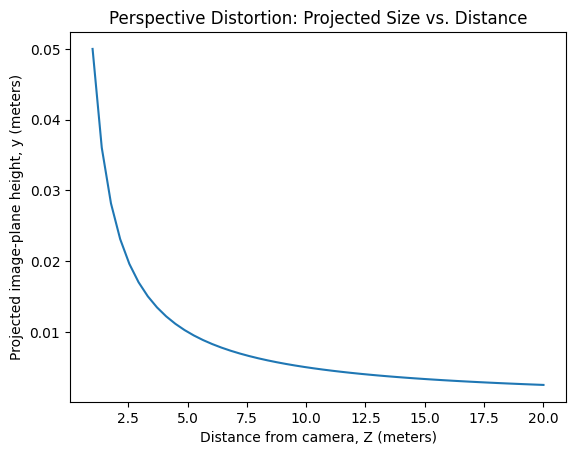

In [2]:
def project(X, Y, Z, f):
    x = f * X / Z
    y = f * Y / Z
    return x, y

f = 0.05   # 50mm focal length, in meters
Y = 1.0    # a 1-meter-tall object, no horizontal offset (X=0)

distances = np.linspace(1, 20, 50)  # 1 to 20 meters away
projected_heights = [project(0, Y, Z, f)[1] for Z in distances]

plt.figure()
plt.plot(distances, projected_heights)
plt.xlabel("Distance from camera, Z (meters)")
plt.ylabel("Projected image-plane height, y (meters)")
plt.title("Perspective Distortion: Projected Size vs. Distance")
plt.show()

This is exactly the perspective distortion effect - the projected height shrinks quickly at first (going from 1m to 2m away roughly halves it), then flattens out at larger distances, following the $1/Z$ relationship in our equations.

### From the Image Plane to Pixels

One more connection worth making explicit: the $(x, y)$ we just computed are *geometric* coordinates in the image plane (in meters here), measured from the principal point. But everywhere else in this primer, we've worked with *pixel* coordinates - `img[row, col]` from notebook 01, with the origin at the top-left corner of the image.

Real cameras convert between the two using two more numbers: a pixel-based focal length ($f_x$, $f_y$ - usually equal, but can differ slightly) and the principal point's pixel location ($c_x$, $c_y$, usually close to the image center):

$u = f_x\frac{X}{Z} + c_x$, $\quad v = f_y\frac{Y}{Z} + c_y$

These four values make up a camera's **intrinsic matrix**, which is exactly what OpenCV's camera calibration tools (and FRC tools like PhotonVision) solve for when you calibrate a camera. We will cover this idea more in the Perception unit. Let's see this in action with made-up but realistic numbers for a 640x480 camera:

In [3]:
def project_to_pixels(X, Y, Z, fx, fy, cx, cy):
    u = fx * X / Z + cx
    v = fy * Y / Z + cy
    return u, v

# a made-up but realistic camera intrinsic matrix for a 640x480 image
fx, fy = 600, 600   # focal length in pixels
cx, cy = 320, 240   # principal point in pixels (roughly the image center)

u, v = project_to_pixels(X=0.5, Y=0.3, Z=5, fx=fx, fy=fy, cx=cx, cy=cy)
print(f"Pixel coordinates: (u={u:.1f}, v={v:.1f})")

Pixel coordinates: (u=380.0, v=276.0)


So a 3D point at half a meter right, 0.3 meters up, and 5 meters away from the camera lands at the pixel coordinates printed above. Note that `u` corresponds to the column and `v` to the row in `img[row, col]` - this is the bridge between the geometry in this notebook and every pixel grid we've worked with since notebook 01.

Now that we understand how image distances map to real-world distances, we are able to move onto a very critical concept that helps us understand how our robot can reconcile images from two different Limelights: **homography**.

## Try It Yourself

Using the `project(X, Y, Z, f)` function from above, fix `Z=10` (10 meters away) and `Y=1` (a 1-meter-tall object). Compute and plot the projected height `y` across a range of focal lengths from `f=0.01` to `f=0.2` (meters). Does increasing the focal length match the "larger f means more zoomed in" claim from earlier in this notebook?

In [4]:
# TODO: fix Z=10 and Y=1, then compute project(0, Y, Z, f) across a range of focal lengths
# TODO: plot focal length vs. projected height

## Resources

- [OpenCV: Camera Calibration and 3D Reconstruction](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html) - the module implementing perspective projection, camera matrices, and related tools.
- [Szeliski, R. *Computer Vision: Algorithms and Applications*, Chapter 2](https://szeliski.org/Book/) - a free, thorough reference on camera models and perspective projection.
- [WPILib: Vision Processing](https://docs.wpilib.org/en/stable/docs/software/vision-processing/introduction/index.html) - FRC-specific documentation connecting these camera concepts to Limelight/PhotonVision setups.